In [18]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

# Datos

In [10]:
from keras.datasets import fashion_mnist

# Carga de datos para entrenamiento y pruebas
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalización: Escalar los píxeles de [0, 255] a [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Lección 3: IMPLEMENTACIÓN DE RN EN PYTHON

In [11]:
## Carga de datos
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

## Preprocesamiento: Normalización a rango [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Definición de la arquitectura (Red Densa)
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)), # Capa de entrada (784 neuronas) [cite: 35]
    layers.Dense(256, activation='relu'), # Capa oculta 1 [cite: 35]
    layers.Dropout(0.3),                  # Regularización (Dropout) [cite: 20, 49]
    layers.Dense(128, activation='relu'), # Capa oculta 2 [cite: 35]
    layers.Dense(10, activation='softmax') # Capa de salida (10 clases) [cite: 35]
])

## Compilación del modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Entrenamiento con validación
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2 # Reservamos el 20% para validar
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8005 - loss: 0.5567 - val_accuracy: 0.8524 - val_loss: 0.4097
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8457 - loss: 0.4190 - val_accuracy: 0.8686 - val_loss: 0.3615
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8602 - loss: 0.3828 - val_accuracy: 0.8685 - val_loss: 0.3656
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8666 - loss: 0.3584 - val_accuracy: 0.8766 - val_loss: 0.3398
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8741 - loss: 0.3455 - val_accuracy: 0.8764 - val_loss: 0.3475
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8774 - loss: 0.3317 - val_accuracy: 0.8732 - val_loss: 0.3457
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8815 - loss: 0.3211 - val_accuracy: 0.8768 - val_loss: 0.3402
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8853 - loss: 0.3080 - val_accuracy: 0.

# Lección 4: REDES NEURONALES CONVOLUTIVAS

In [14]:
# Remodelado de los datos para la CNN (añadir el canal de color: gris)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Construcción de la CNN
model_cnn = models.Sequential([
    # Primera capa convolucional: Detecta bordes y texturas simples
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)), # Reduce dimensiones para eficiencia

    # Segunda capa convolucional: Detecta formas más complejas
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Capas de clasificación final
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4), # Regularización para evitar sobreajuste [cite: 20]
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenamiento
history_cnn = model_cnn.fit(X_train_cnn, y_train, epochs=15,
                            validation_data=(X_test_cnn, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.8092 - loss: 0.5229 - val_accuracy: 0.8634 - val_loss: 0.3705
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.8728 - loss: 0.3515 - val_accuracy: 0.8880 - val_loss: 0.3049
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.8877 - loss: 0.3048 - val_accuracy: 0.8940 - val_loss: 0.2927
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8989 - loss: 0.2750 - val_accuracy: 0.9019 - val_loss: 0.2730
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9076 - loss: 0.2500 - val_accuracy: 0.8996 - val_loss: 0.2761
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9146 - loss: 0.2326 - val_accuracy: 0.8992 - val_loss: 0.2643
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9189 - loss: 0.2189 - val_accuracy: 0.9068 - val_loss: 0.2488
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9226 -

In [19]:
def predict_external_image_fixed(img_path, model, is_cnn=True):
    # 1. Cargar la imagen a color
    img_rgb = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

    # 2. Convertir a Escala de Grises
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # 3. CRÍTICO: Invertir Colores.
    # Pasamos de [Fondo Blanco, Ropa Oscura] a [Fondo Negro, Ropa Clara]
    # para que coincida con la distribución de Fashion-MNIST.
    img_inverted = cv2.bitwise_not(img_gray)

    # 4. Redimensionar a 28x28 (con interpolación de área para no perder detalles)
    img_resized = cv2.resize(img_inverted, (28, 28), interpolation=cv2.INTER_AREA)

    # 5. Normalizar al rango [0, 1]
    img_normalized = img_resized.astype('float32') / 255.0

    # 6. Remodelar para el modelo (añadir batch y canal de color si es CNN)
    if is_cnn:
        img_final = img_normalized.reshape(1, 28, 28, 1)
    else:
        # Si usas el modelo Denso de la Lección 3
        img_final = img_normalized.reshape(1, 784)

    # 7. Predicción
    prediction = model.predict(img_final)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction)

    # Diccionario de clases oficial de Fashion-MNIST
    classes = ['T-shirt/top (Camiseta)', 'Trouser (Pantalón)', 'Pullover (Suéter)',
               'Dress (Vestido)', 'Coat (Abrigo)', 'Sandal (Sandalia)',
               'Shirt (Camisa)', 'Sneaker (Zapatilla)', 'Bag (Bolso)', 'Ankle boot (Botín)']

    # 8. Visualización de los pasos (para tu documentación técnica )
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original RGB")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_inverted, cmap='gray')
    plt.title("Invertida (Input real)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Input Final 28x28\nPred: {classes[class_idx]}\nConf: {confidence:.2f}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


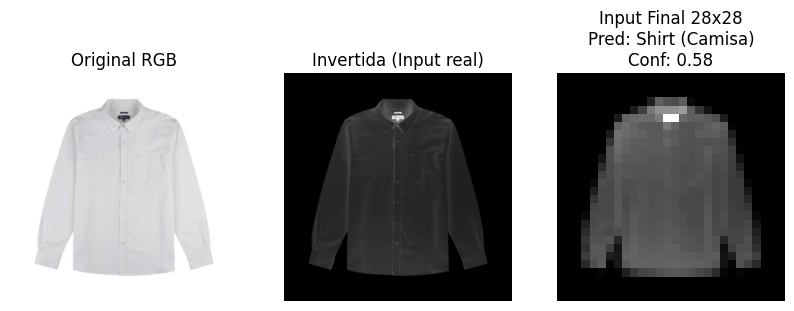

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


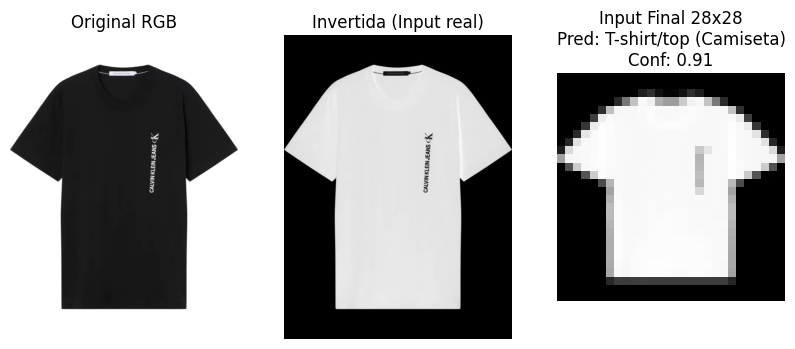

In [20]:
# --- CÓMO LLAMARLO EN COLAB ---
# Suponiendo que tu modelo CNN se llama 'model_cnn'
predict_external_image_fixed('/content/camisa1.webp', model_cnn, is_cnn=True)
predict_external_image_fixed('/content/polera1.webp', model_cnn, is_cnn=True)